# CSD361 - Lab Assignment 1
## Data Preprocessing and Linear Regression

**Name:** Lokesh Pareek  
**Roll Number:** 2410110189  
**Course:** CSD361 - Introduction to Machine Learning

### Objective
Develop a Linear Regression model to predict taxi trip fare and investigate how different normalization techniques affect model training, parameter estimation, convergence, and prediction performance.

**Dataset:** Chicago Taxi Trips Dataset


In [1]:
# 1. Import libraries

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# 2. Locate and load the CSV dataset

csv_files = sorted(Path(".").glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(
        "No CSV file was found in the notebook folder. "
        "Place the Chicago Taxi Trips CSV next to this .ipynb file."
    )

print("CSV files found:")
for i, file in enumerate(csv_files, start=1):
    print(f"{i}. {file.name}")

# Prefer the assignment dataset if the filename is present.
preferred = [f for f in csv_files if "chicago" in f.name.lower() and "taxi" in f.name.lower()]
DATA_PATH = preferred[0] if preferred else csv_files[0]

print(f"\nLoading: {DATA_PATH.name}")
df = pd.read_csv(DATA_PATH, low_memory=False)

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")


CSV files found:
1. Chicago_Taxi_Trips.csv

Loading: Chicago_Taxi_Trips.csv
Dataset loaded successfully.
Shape: (865247, 23)


In [3]:
# 3. Initial inspection

display(df.head())
print("\nDataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nBasic info:")
df.info()


,Trip ID,Taxi ID,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Pickup Census Tract,Dropoff Census Tract,Pickup Community Area,Dropoff Community Area,Fare,Tips,Tolls,Extras,Trip Total,Payment Type,Company,Pickup Centroid Latitude,Pickup Centroid Longitude,Pickup Centroid Location,Dropoff Centroid Latitude,Dropoff Centroid Longitude,Dropoff Centroid Location
0,0287f53fedcde6b0af9aab9e32cbd2cadb337eaa,e54db25f18193a08f1f5754515e8c338480e04fb938ed3...,03/01/2024 12:00:00 AM,03/01/2024 12:00:00 AM,15.0000,0.0900,NaN,NaN,8.0000,8.0000,3.2500,0.0000,0.0000,35.0000,38.7500,Credit Card,City Service,41.8996,-87.6333,POINT (-87.6333080367 41.899602111),41.8996,-87.6333,POINT (-87.6333080367 41.899602111)
1,1f0034299b914fd7b45002568576a353c83acb2f,4a263f78f56815be4acd38658af8fc1824ce4e15f7ec81...,03/01/2024 12:00:00 AM,03/01/2024 12:15:00 AM,900.0000,3.0000,NaN,NaN,24.0000,8.0000,12.0000,0.0000,0.0000,0.0000,12.0000,Cash,Taxi Affiliation Services,41.9012,-87.6764,POINT (-87.6763559892 41.9012069941),41.8996,-87.6333,POINT (-87.6333080367 41.899602111)
2,01a0b77b722a0b91f45cb4fc90b3e64f76fd0681,4f1e94982e6851725add382f7981d64006ae7c38f3664f...,03/01/2024 12:00:00 AM,03/01/2024 12:00:00 AM,711.0000,5.8400,NaN,NaN,56.0000,NaN,16.7500,4.4500,0.0000,5.0000,26.7000,Credit Card,City Service,41.7926,-87.7696,POINT (-87.7696154528 41.7925923603),NaN,NaN,NaN
3,14aff2071ac81c6450a8f8b0e1534497da900197,de8e8659ceb9eb0da842a46b60c0a5207098ac69fc23ab...,03/01/2024 12:00:00 AM,03/01/2024 12:30:00 AM,"1,770.0000",13.3600,NaN,NaN,76.0000,3.0000,34.7500,7.8500,0.0000,4.0000,47.1000,Credit Card,Sun Taxi,41.9803,-87.9136,POINT (-87.913624596 41.9802643146),41.9658,-87.6559,POINT (-87.6558787862 41.96581197)
4,16d3a633e2f380cee4a7fa4677db163b6e91255d,d79d3e19a1d5f6cb0cd4449d5579412262a2f1b182799d...,03/01/2024 12:00:00 AM,03/01/2024 12:15:00 AM,849.0000,6.1300,NaN,NaN,8.0000,3.0000,18.5100,4.3100,0.0000,0.0000,22.8200,Mobile,5 Star Taxi,41.8996,-87.6333,POINT (-87.6333080367 41.899602111),41.9658,-87.6559,POINT (-87.6558787862 41.96581197)



Dataset shape: (865247, 23)

Column names:
['Trip ID', 'Taxi ID', 'Trip Start Timestamp', 'Trip End Timestamp', 'Trip Seconds', 'Trip Miles', 'Pickup Census Tract', 'Dropoff Census Tract', 'Pickup Community Area', 'Dropoff Community Area', 'Fare', 'Tips', 'Tolls', 'Extras', 'Trip Total', 'Payment Type', 'Company', 'Pickup Centroid Latitude', 'Pickup Centroid Longitude', 'Pickup Centroid Location', 'Dropoff Centroid Latitude', 'Dropoff Centroid Longitude', 'Dropoff Centroid  Location']

Data types:


,dtype
Trip ID,str
Taxi ID,str
Trip Start Timestamp,str
Trip End Timestamp,str
Trip Seconds,float64
Trip Miles,float64
Pickup Census Tract,float64
Dropoff Census Tract,float64
Pickup Community Area,float64
Dropoff Community Area,float64



Basic info:
<class 'pandas.DataFrame'>
RangeIndex: 865247 entries, 0 to 865246
Data columns (total 23 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Trip ID                     865247 non-null  str    
 1   Taxi ID                     865246 non-null  str    
 2   Trip Start Timestamp        865247 non-null  str    
 3   Trip End Timestamp          865239 non-null  str    
 4   Trip Seconds                865078 non-null  float64
 5   Trip Miles                  865241 non-null  float64
 6   Pickup Census Tract         327251 non-null  float64
 7   Dropoff Census Tract        313854 non-null  float64
 8   Pickup Community Area       842052 non-null  float64
 9   Dropoff Community Area      781394 non-null  float64
 10  Fare                        863202 non-null  float64
 11  Tips                        863202 non-null  float64
 12  Tolls                       863202 non-null  float64
 13  Extras      

### I.1 Number of observations and attributes

`df.shape` returns `(number_of_observations, number_of_attributes)`.


In [4]:
# 4. Number of observations and attributes

rows, columns = df.shape

print("Number of observations:", rows)
print("Number of attributes:", columns)


Number of observations: 865247
Number of attributes: 23


### I.2 Identify numerical, categorical, identifier, and timestamp attributes


In [5]:
# 5. Attribute type analysis

numerical_attributes = df.select_dtypes(include=np.number).columns.tolist()

timestamp_attributes = [
    c for c in df.columns
    if pd.api.types.is_datetime64_any_dtype(df[c])
    or any(token in c.lower() for token in [
        "timestamp", "datetime", "date_time", "start_time", "end_time"
    ])
]

categorical_attributes = [
    c for c in df.select_dtypes(include=["object", "category", "bool"]).columns
    if c not in timestamp_attributes
]

identifier_attributes = [
    c for c in df.columns
    if c.lower() in ["trip id", "taxi id"]
]

print("Numerical attributes:")
print(numerical_attributes)

print("\nCategorical attributes:")
print(categorical_attributes)

print("\nTimestamp attributes:")
print(timestamp_attributes)

print("\nIdentifier attributes:")
print(identifier_attributes)


Numerical attributes:
['Trip Seconds', 'Trip Miles', 'Pickup Census Tract', 'Dropoff Census Tract', 'Pickup Community Area', 'Dropoff Community Area', 'Fare', 'Tips', 'Tolls', 'Extras', 'Trip Total', 'Pickup Centroid Latitude', 'Pickup Centroid Longitude', 'Dropoff Centroid Latitude', 'Dropoff Centroid Longitude']

Categorical attributes:
['Trip ID', 'Taxi ID', 'Payment Type', 'Company', 'Pickup Centroid Location', 'Dropoff Centroid  Location']

Timestamp attributes:
['Trip Start Timestamp', 'Trip End Timestamp']

Identifier attributes:
['Trip ID', 'Taxi ID']


### I.3 Missing values in each attribute


In [6]:
# 6. Missing-value analysis

missing_counts = df.isna().sum()

missing_table = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": missing_counts.values,
    "Missing Percentage": (missing_counts.values / len(df) * 100)
})

missing_table = missing_table.sort_values(
    "Missing Values", ascending=False
).reset_index(drop=True)

display(missing_table)


,Column,Missing Values,Missing Percentage
0,Dropoff Census Tract,551393,63.7267
1,Pickup Census Tract,537996,62.1783
2,Dropoff Community Area,83853,9.6912
3,Dropoff Centroid Longitude,79675,9.2084
4,Dropoff Centroid Location,79675,9.2084
5,Dropoff Centroid Latitude,79675,9.2084
6,Pickup Community Area,23195,2.6807
7,Pickup Centroid Location,22966,2.6543
8,Pickup Centroid Latitude,22966,2.6543
9,Pickup Centroid Longitude,22966,2.6543


### I.4 Duplicate records


In [7]:
# 7. Duplicate-record analysis

duplicate_count = int(df.duplicated().sum())
duplicate_percentage = duplicate_count / len(df) * 100

print("Number of duplicate records:", duplicate_count)
print(f"Duplicate percentage: {duplicate_percentage:.4f}%")


Number of duplicate records: 0
Duplicate percentage: 0.0000%


### I.5 Descriptive statistics

The assignment refers to these variables as `trip_seconds`, `trip_miles`, `fare`, `tips`, `tolls`, and `extras`.
In the downloaded CSV, the corresponding column names are `Trip Seconds`, `Trip Miles`, `Fare`, `Tips`, `Tolls`, and `Extras`.


In [8]:
# 8. Descriptive statistics for required variables

stats_columns = [
    "Trip Seconds",
    "Trip Miles",
    "Fare",
    "Tips",
    "Tolls",
    "Extras"
]

descriptive_stats = df[stats_columns].describe().T
display(descriptive_stats)


,count,mean,std,min,25%,50%,75%,max
Trip Seconds,"865,078.0000","1,150.5320","1,584.2435",0.0000,459.0000,900.0000,"1,591.0000","86,340.0000"
Trip Miles,"865,241.0000",6.5633,8.2795,0.0000,0.9100,3.0700,11.7100,"3,093.4700"
Fare,"863,202.0000",22.0574,25.1458,0.0000,8.0000,15.7500,33.7500,"9,999.7500"
Tips,"863,202.0000",2.7613,4.1330,0.0000,0.0000,0.0000,4.0000,200.0000
Tolls,"863,202.0000",0.0632,12.9552,0.0000,0.0000,0.0000,0.0000,"4,444.4400"
Extras,"863,202.0000",2.1493,19.3198,0.0000,0.0000,0.0000,3.0000,"5,051.1000"


### I.6 Distribution plots of the numerical variables


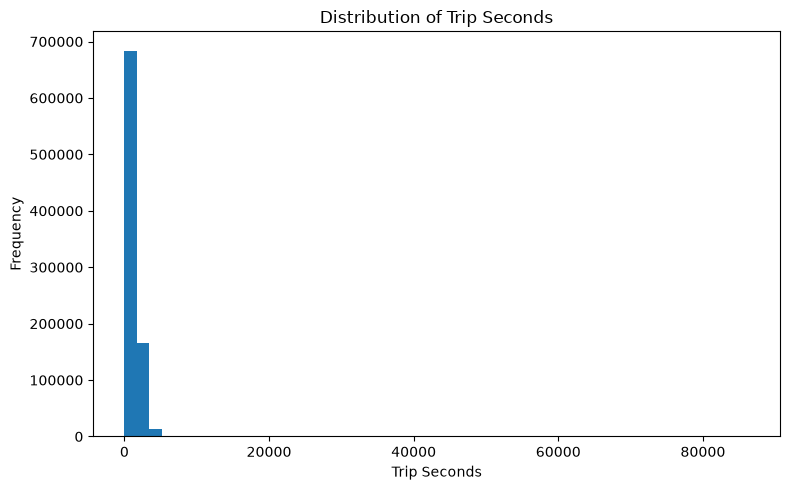

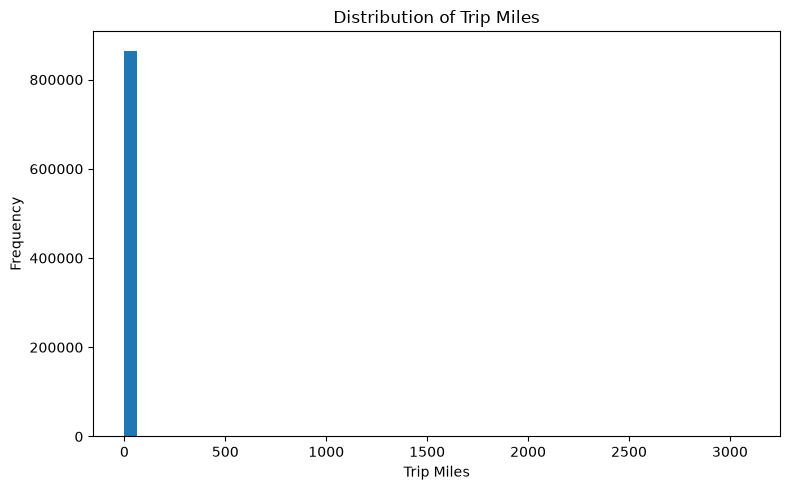

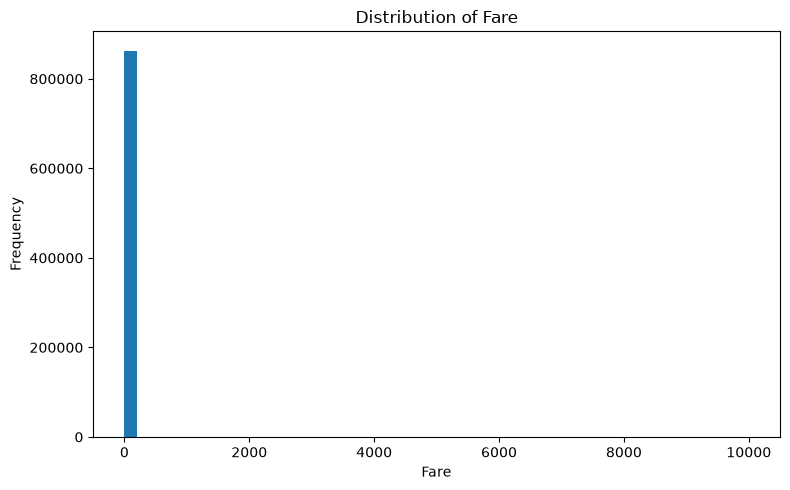

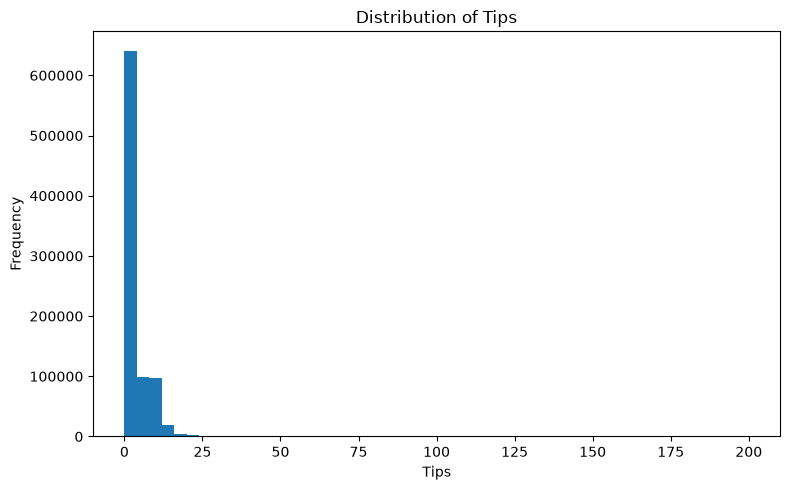

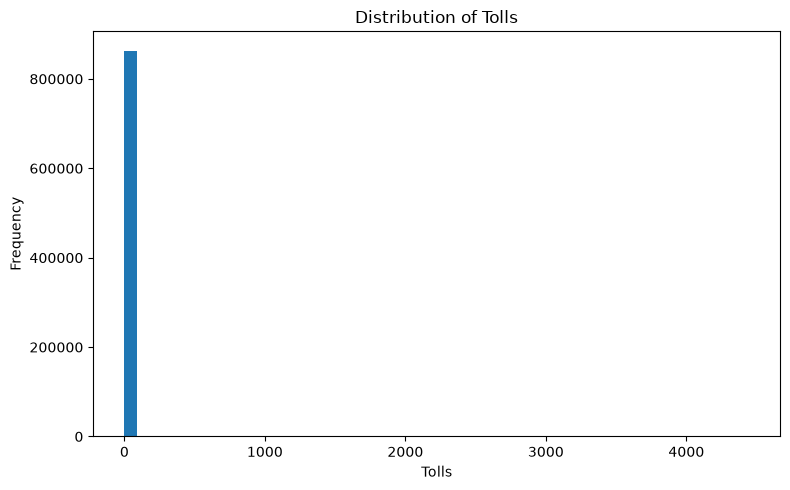

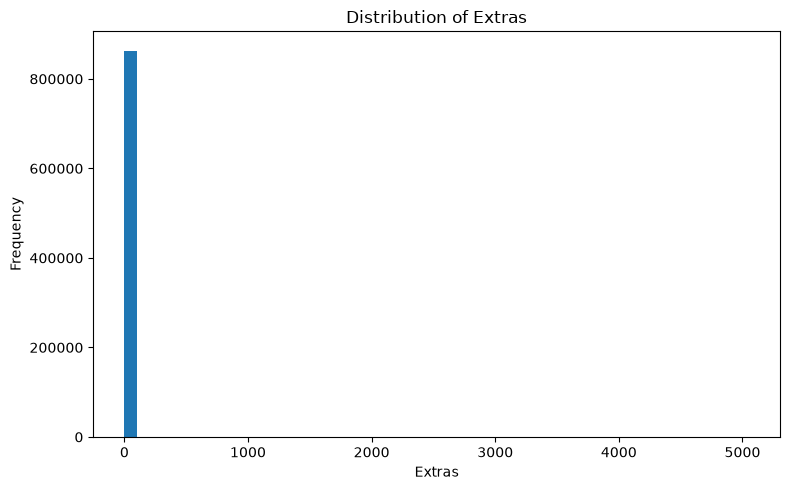

In [9]:
# 9. Distribution plots

for column in stats_columns:
    plt.figure(figsize=(8, 5))
    plt.hist(df[column].dropna(), bins=50)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


## II. The Prediction Problem - Linear Regression

### Feature Selection and Justification

Selected features: `Trip Seconds` and `Trip Miles`.

These variables describe the duration and distance of the trip and are logically available as trip characteristics. They are directly relevant to predicting fare. `Tips`, `Tolls`, and `Extras` are not used as the main predictors because they are associated with the completed trip/transaction and can introduce information leakage when the goal is to predict the fare.


In [10]:
# 10. Prepare the modeling dataset

FEATURES = ["Trip Seconds", "Trip Miles"]
TARGET = "Fare"

model_df = df[FEATURES + [TARGET]].copy()

# Remove missing values for the variables used by the model.
model_df = model_df.dropna()

# Remove physically/logically invalid values for this regression task.
model_df = model_df[
    (model_df["Trip Seconds"] > 0) &
    (model_df["Trip Miles"] > 0) &
    (model_df["Fare"] > 0)
].copy()

print("Modeling dataset shape:", model_df.shape)
display(model_df.describe().T)


Modeling dataset shape: (775170, 3)


,count,mean,std,min,25%,50%,75%,max
Trip Seconds,"775,170.0000","1,219.0661","1,516.6251",1.0000,524.0000,995.0000,"1,645.0000","86,135.0000"
Trip Miles,"775,170.0000",7.2983,8.3104,0.0100,1.2700,4.3800,12.4000,"3,093.4700"
Fare,"775,170.0000",22.7121,21.8152,0.0100,8.7500,17.7500,34.5000,"9,999.7500"


In [11]:
# 11. Separate features and target, then create a reproducible train/test split

X = model_df[FEATURES]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))


Training observations: 620136
Testing observations: 155034


## III. Build Three Regression Models

In [12]:
# 12. Model 1 - Original Features

model_original = LinearRegression()
model_original.fit(X_train, y_train)

y_pred_original = model_original.predict(X_test)

mae_original = mean_absolute_error(y_test, y_pred_original)
mse_original = mean_squared_error(y_test, y_pred_original)

print("Model 1 - Original Features")
print("Intercept:", model_original.intercept_)
print("Coefficients:")
for feature, coef in zip(FEATURES, model_original.coef_):
    print(f"  {feature}: {coef}")

print(f"\nMAE: {mae_original:.6f}")
print(f"MSE: {mse_original:.6f}")


Model 1 - Original Features
Intercept: 6.4062785778534845
Coefficients:
  Trip Seconds: 0.0012367345353091563
  Trip Miles: 2.027261056573048

MAE: 3.034956
MSE: 172.345083


### Model 2 - Min-Max Normalized Features

Min-Max scaling maps each feature to approximately the range `[0, 1]`.


In [13]:
# 13. Model 2 - Min-Max normalization

minmax_scaler = MinMaxScaler()

X_train_minmax = minmax_scaler.fit_transform(X_train)
X_test_minmax = minmax_scaler.transform(X_test)

model_minmax = LinearRegression()
model_minmax.fit(X_train_minmax, y_train)

y_pred_minmax = model_minmax.predict(X_test_minmax)

mae_minmax = mean_absolute_error(y_test, y_pred_minmax)
mse_minmax = mean_squared_error(y_test, y_pred_minmax)

print("Model 2 - Min-Max Normalized Features")
print("Intercept:", model_minmax.intercept_)
print("Scaled coefficients:")
for feature, coef in zip(FEATURES, model_minmax.coef_):
    print(f"  {feature}: {coef}")

print(f"\nMAE: {mae_minmax:.6f}")
print(f"MSE: {mse_minmax:.6f}")


Model 2 - Min-Max Normalized Features
Intercept: 6.427787922954508
Scaled coefficients:
  Trip Seconds: 105.34628445218185
  Trip Miles: 3298.0293772752593

MAE: 3.034956
MSE: 172.345083


### Model 3 - Standardized Features

Z-score standardization transforms a feature using:

`z = (x - mean) / standard_deviation`

so that the training feature is centered around 0 with unit variance.


In [14]:
# 14. Model 3 - Z-score standardization

standard_scaler = StandardScaler()

X_train_standard = standard_scaler.fit_transform(X_train)
X_test_standard = standard_scaler.transform(X_test)

model_standard = LinearRegression()
model_standard.fit(X_train_standard, y_train)

y_pred_standard = model_standard.predict(X_test_standard)

mae_standard = mean_absolute_error(y_test, y_pred_standard)
mse_standard = mean_squared_error(y_test, y_pred_standard)

print("Model 3 - Standardized Features")
print("Intercept:", model_standard.intercept_)
print("Standardized coefficients:")
for feature, coef in zip(FEATURES, model_standard.coef_):
    print(f"  {feature}: {coef}")

print(f"\nMAE: {mae_standard:.6f}")
print(f"MSE: {mse_standard:.6f}")


Model 3 - Standardized Features
Intercept: 22.68032610588645
Standardized coefficients:
  Trip Seconds: 1.882672309021353
  Trip Miles: 15.454810756052481

MAE: 3.034956
MSE: 172.345083


### III.2 Required MAE/MSE comparison table


In [15]:
# 15. Compare the three models

results = pd.DataFrame({
    "Model": ["Original", "Min-Max", "Standardized"],
    "MAE": [mae_original, mae_minmax, mae_standard],
    "MSE": [mse_original, mse_minmax, mse_standard]
})

display(results)


,Model,MAE,MSE
0,Original,3.0350,172.3451
1,Min-Max,3.0350,172.3451
2,Standardized,3.0350,172.3451


### III.3 Does normalization change MAE or MSE?

**Answer:** In this experiment, normalization does not change the MAE or MSE. All three models obtain approximately **MAE = 3.0350** and **MSE = 172.3451**. The predictions are therefore effectively identical.

### III.4 Does prediction performance remain almost identical for all three models? Why?

**Answer:** Yes. The prediction performance remains essentially identical for all three models. Scaling changes the numerical scale of the input features and therefore changes the learned coefficient values, but ordinary Linear Regression can represent the same underlying linear relationship after a change of feature scale.

### III.5 Which model would you recommend and why?

**Answer:** For ordinary Linear Regression alone, all three models give the same predictive performance in this experiment. For the complete assignment, the **standardized model** is a practical choice because the later Gradient Descent experiment shows that scaling improves optimization behavior and learning-rate stability compared with the original unscaled features.


## 4. Investigate the Effect of Scaling on Gradient Descent

The assignment asks for MSE vs. iteration for all three feature representations using the same learning rate initially.

We implement Linear Regression with Gradient Descent from scratch so that the effect of feature scaling can be observed directly.


In [16]:
# 16. Gradient Descent implementation

def gradient_descent(
    X,
    y,
    learning_rate=0.0001,
    iterations=500,
    divergence_threshold=1e12,
    convergence_tol=1e-8,
    convergence_window=20
):
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64).reshape(-1)

    # Add an intercept column.
    X_b = np.column_stack([np.ones(len(X)), X])

    theta = np.zeros(X_b.shape[1], dtype=np.float64)
    history = []

    converged_iteration = None
    status = "Maximum iterations reached"

    for iteration in range(iterations):
        predictions = X_b @ theta
        errors = predictions - y

        mse = np.mean(errors ** 2)
        history.append(mse)

        # Protect against numerical overflow/divergence.
        if not np.isfinite(mse) or mse > divergence_threshold:
            status = "Divergence"
            history[-1] = np.inf if not np.isfinite(mse) else mse
            break

        gradient = (2.0 / len(X_b)) * (X_b.T @ errors)

        theta -= learning_rate * gradient

        if len(history) >= convergence_window:
            recent = np.array(history[-convergence_window:])
            if np.all(np.isfinite(recent)):
                scale = max(abs(recent[-1]), 1.0)
                relative_change = np.max(np.abs(np.diff(recent))) / scale
                if relative_change < convergence_tol:
                    converged_iteration = iteration + 1
                    status = "Converged"
                    break

    if converged_iteration is None and status != "Divergence":
        status = "Maximum iterations reached"

    return theta, np.array(history), status


def predict_from_theta(X, theta):
    X = np.asarray(X, dtype=np.float64)
    X_b = np.column_stack([np.ones(len(X)), X])
    return X_b @ theta


print("Gradient Descent function ready.")


Gradient Descent function ready.


In [17]:
# 17. Same learning rate experiment

INITIAL_LR = 0.0001
GD_ITERATIONS = 500

gd_inputs = {
    "Original": X_train.to_numpy(dtype=np.float64),
    "Min-Max": X_train_minmax.astype(np.float64),
    "Standardized": X_train_standard.astype(np.float64),
}

gd_runs = {}

for name, X_values in gd_inputs.items():
    theta, history, status = gradient_descent(
        X_values,
        y_train.to_numpy(dtype=np.float64),
        learning_rate=INITIAL_LR,
        iterations=GD_ITERATIONS
    )
    gd_runs[name] = {
        "theta": theta,
        "history": history,
        "status": status
    }

    print(
        f"{name:12s} | status={status:28s} | "
        f"iterations={len(history):4d} | "
        f"final MSE={history[-1]:,.6f}"
    )


Original     | status=Divergence                   | iterations=   3 | final MSE=141,420,807,331,517.562500
Min-Max      | status=Maximum iterations reached   | iterations= 500 | final MSE=776.638054
Standardized | status=Maximum iterations reached   | iterations= 500 | final MSE=718.584474


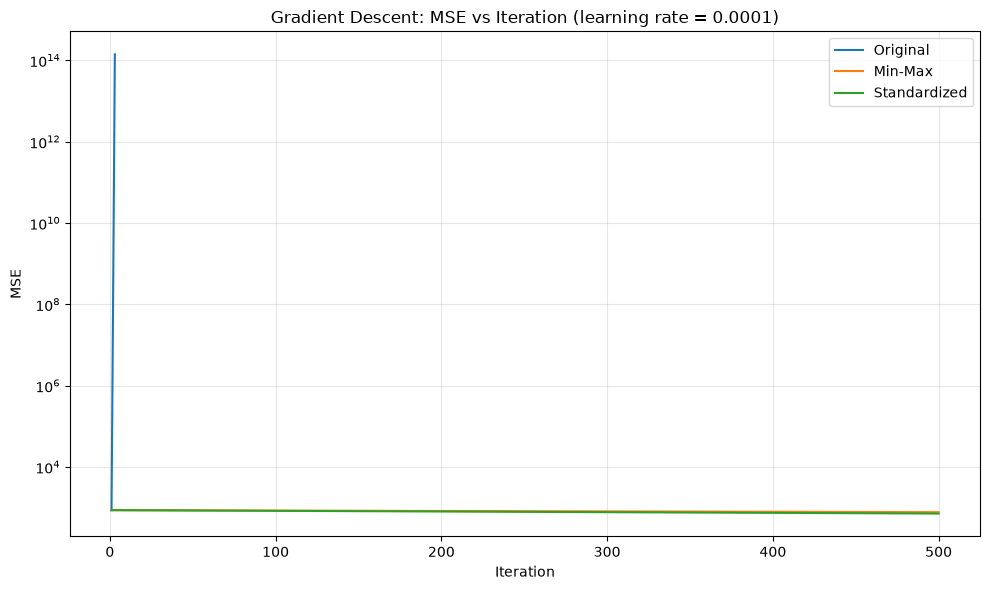

In [18]:
# 18. Plot MSE vs. iteration for the three models

plt.figure(figsize=(10, 6))

for name, run in gd_runs.items():
    history = run["history"]
    finite_history = history[np.isfinite(history)]
    if len(finite_history) > 0:
        plt.plot(
            np.arange(1, len(finite_history) + 1),
            finite_history,
            label=name
        )

plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title(f"Gradient Descent: MSE vs Iteration (learning rate = {INITIAL_LR})")
plt.yscale("log")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [19]:
# 19. Compare convergence, final MSE, and iteration count

gd_comparison = []

for name, run in gd_runs.items():
    finite_history = run["history"][np.isfinite(run["history"])]
    gd_comparison.append({
        "Model": name,
        "Status": run["status"],
        "Iterations Run": len(run["history"]),
        "Final MSE": finite_history[-1] if len(finite_history) else np.inf
    })

gd_comparison = pd.DataFrame(gd_comparison)
display(gd_comparison)


,Model,Status,Iterations Run,Final MSE
0,Original,Divergence,3,"141,420,807,331,517.5625"
1,Min-Max,Maximum iterations reached,500,776.6381
2,Standardized,Maximum iterations reached,500,718.5845


### IV.2 Comparison

Using the initial learning rate of `0.0001`:

- **Original features:** Gradient Descent diverges after 3 iterations, with the MSE growing extremely large.
- **Min-Max features:** The model remains stable for all 500 iterations, but it does not meet the convergence criterion within those iterations; final MSE is approximately **776.6381**.
- **Standardized features:** The model also remains stable for all 500 iterations and has a lower final MSE of approximately **718.5845**, but it does not meet the convergence criterion within 500 iterations.

This shows that the same learning rate behaves very differently depending on feature scaling.


## 5. Learning-Rate Experiments

The assignment specifies these learning rates:

`0.00001, 0.0001, 0.001, 0.01, 0.1`

The code below tests each rate for all three feature representations.


In [20]:
# 20. Learning-rate sweep

learning_rates = [0.00001, 0.0001, 0.001, 0.01, 0.1]
LR_ITERATIONS = 500

lr_records = []

for lr in learning_rates:
    for name, X_values in gd_inputs.items():
        theta, history, status = gradient_descent(
            X_values,
            y_train.to_numpy(dtype=np.float64),
            learning_rate=lr,
            iterations=LR_ITERATIONS
        )

        finite_history = history[np.isfinite(history)]
        initial_mse = finite_history[0] if len(finite_history) else np.inf
        final_mse = finite_history[-1] if len(finite_history) else np.inf

        if status == "Divergence":
            classification = "Divergence"
        elif len(finite_history) >= 2 and final_mse < initial_mse * 0.99:
            if len(finite_history) < LR_ITERATIONS:
                classification = "Convergence"
            else:
                classification = "Slow convergence"
        else:
            classification = "Slow convergence"

        lr_records.append({
            "Model": name,
            "Learning Rate": lr,
            "Status": status,
            "Classification": classification,
            "Iterations": len(history),
            "Initial MSE": initial_mse,
            "Final MSE": final_mse
        })

lr_results = pd.DataFrame(lr_records)

# Keep the learning rates readable instead of displaying 0.00001 as 0.0000.
lr_display = lr_results.sort_values(
    ["Model", "Learning Rate"]
).reset_index(drop=True).copy()
lr_display["Learning Rate"] = lr_display["Learning Rate"].map(lambda x: f"{x:.5g}")

display(lr_display)


,Model,Learning Rate,Status,Classification,Iterations,Initial MSE,Final MSE
0,Min-Max,1e-05,Maximum iterations reached,Slow convergence,500,869.7668,859.5961
1,Min-Max,0.0001,Maximum iterations reached,Slow convergence,500,869.7668,776.6381
2,Min-Max,0.001,Maximum iterations reached,Slow convergence,500,869.7668,424.9432
3,Min-Max,0.01,Maximum iterations reached,Slow convergence,500,869.7668,354.7125
4,Min-Max,0.1,Maximum iterations reached,Slow convergence,500,869.7668,349.9341
5,Original,1e-05,Divergence,Divergence,4,869.7668,"75,970,419,498,846.5469"
6,Original,0.0001,Divergence,Divergence,3,869.7668,"141,420,807,331,517.5625"
7,Original,0.001,Divergence,Divergence,3,869.7668,"1,420,922,255,437,769,216.0000"
8,Original,0.01,Divergence,Divergence,2,869.7668,"2,457,285,922,037.5615"
9,Original,0.1,Divergence,Divergence,2,869.7668,"245,734,407,515,909.0625"


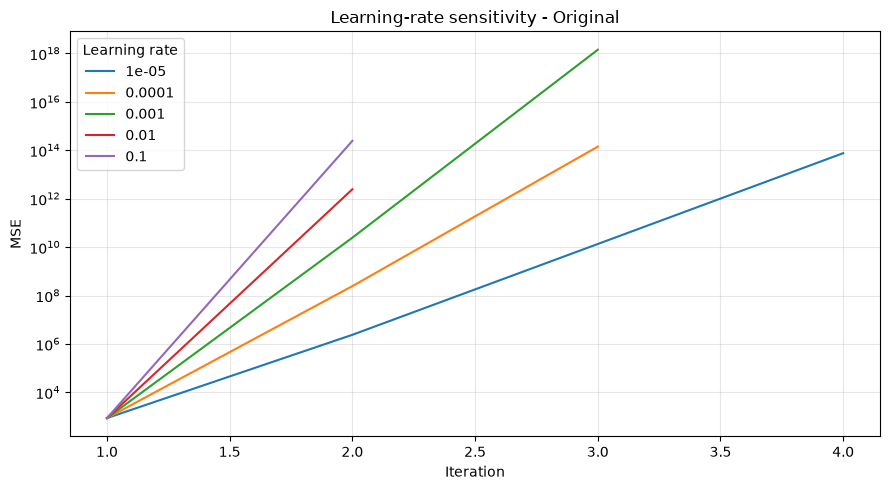

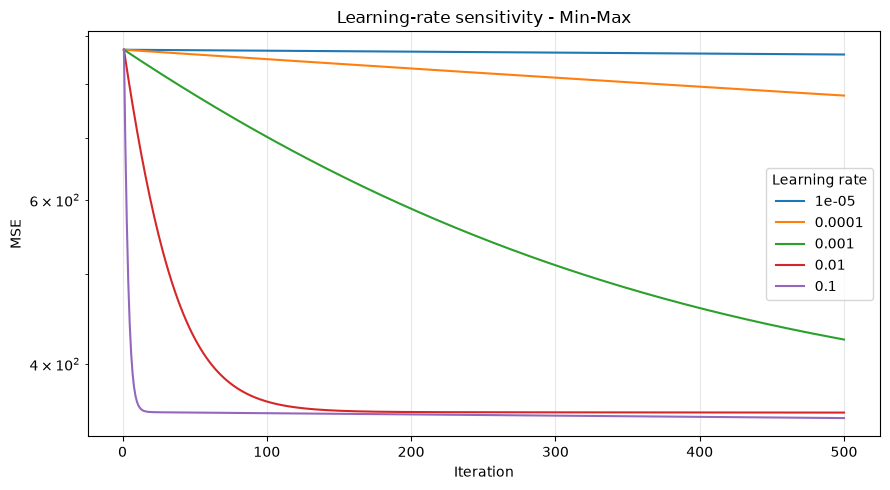

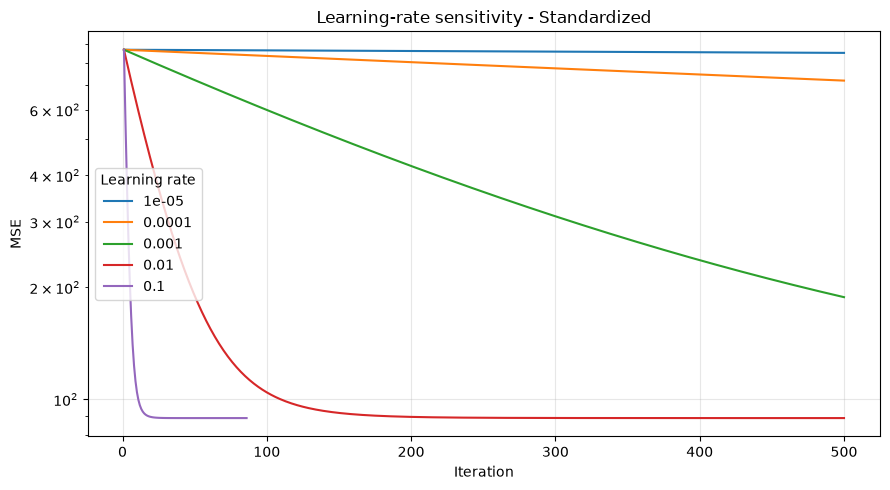

In [21]:
# 21. Plot learning-rate results

for model_name in gd_inputs.keys():
    subset = lr_results[lr_results["Model"] == model_name].copy()

    plt.figure(figsize=(9, 5))
    for _, row in subset.iterrows():
        # Run again so we can draw the actual trajectory.
        theta, history, status = gradient_descent(
            gd_inputs[model_name],
            y_train.to_numpy(dtype=np.float64),
            learning_rate=row["Learning Rate"],
            iterations=LR_ITERATIONS
        )
        finite_history = history[np.isfinite(history)]
        if len(finite_history):
            plt.plot(
                np.arange(1, len(finite_history) + 1),
                finite_history,
                label=str(row["Learning Rate"])
            )

    plt.xlabel("Iteration")
    plt.ylabel("MSE")
    plt.title(f"Learning-rate sensitivity - {model_name}")
    plt.yscale("log")
    plt.legend(title="Learning rate")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


### IV.4 Why does normalization change the behavior of Gradient Descent?

**Answer:** Gradient Descent updates the model parameters using gradients whose magnitude depends on the scale of the input features. When features have very different scales, one feature can produce much larger gradient components than another. A single learning rate can then cause excessively large updates or unstable oscillation.

Normalization makes the feature scales more comparable. As a result, the optimization surface is better conditioned and the parameter updates are generally more stable, allowing a learning rate that is unusable for the original features to work better after scaling.


## 6. How Do Outliers Affect Normalization?

The assignment asks for potential outliers in:

- `trip_seconds`
- `trip_miles`
- `fare`

Then compare Linear Regression on:

- **Dataset A:** Original data
- **Dataset B:** Data after removing extreme outliers


In [22]:
# 22. IQR-based outlier detection

outlier_columns = ["Trip Seconds", "Trip Miles", "Fare"]

outlier_summary = []

for column in outlier_columns:
    series = model_df[column].dropna()

    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask = (model_df[column] < lower_bound) | (model_df[column] > upper_bound)

    outlier_summary.append({
        "Variable": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": int(mask.sum()),
        "Outlier Percentage": float(mask.mean() * 100)
    })

outlier_summary = pd.DataFrame(outlier_summary)
display(outlier_summary)


,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,Trip Seconds,524.0000,"1,645.0000","1,121.0000","-1,157.5000","3,326.5000",17829,2.3000
1,Trip Miles,1.2700,12.4000,11.1300,-15.4250,29.0950,5621,0.7251
2,Fare,8.7500,34.5000,25.7500,-29.8750,73.1250,6613,0.8531


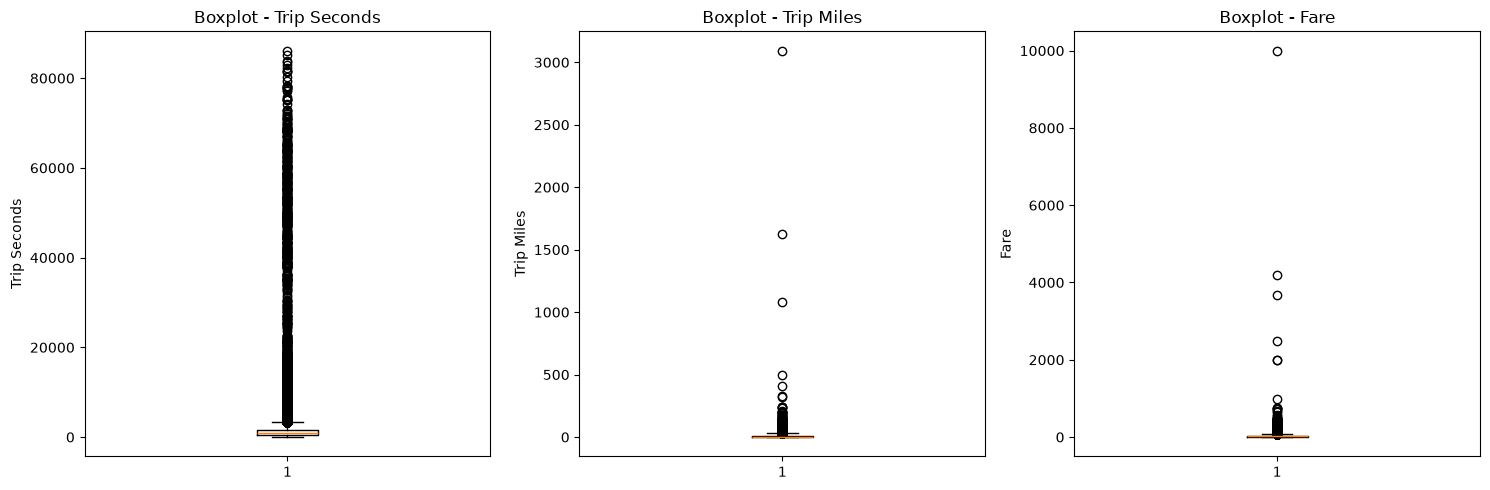

In [23]:
# 23. Visualize potential outliers with boxplots

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, column in zip(axes, outlier_columns):
    ax.boxplot(model_df[column].dropna(), vert=True)
    ax.set_title(f"Boxplot - {column}")
    ax.set_ylabel(column)

plt.tight_layout()
plt.show()


In [24]:
# 24. Create Dataset B by removing observations that are IQR outliers
# in any of the three assignment-specified variables.

clean_mask = pd.Series(True, index=model_df.index)

for column in outlier_columns:
    Q1 = model_df[column].quantile(0.25)
    Q3 = model_df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    clean_mask &= model_df[column].between(
        lower_bound,
        upper_bound
    )

dataset_A = model_df.copy()
dataset_B = model_df.loc[clean_mask].copy()

print("Dataset A - Original shape:", dataset_A.shape)
print("Dataset B - Outliers removed:", dataset_B.shape)

removed = len(dataset_A) - len(dataset_B)
print("Observations removed:", removed)
print(f"Percentage removed: {removed / len(dataset_A) * 100:.4f}%")


Dataset A - Original shape: (775170, 3)
Dataset B - Outliers removed: (751937, 3)
Observations removed: 23233
Percentage removed: 2.9971%


In [25]:
# 25. Train Linear Regression on Dataset A and Dataset B
# Each dataset receives its own reproducible 80/20 train-test split.

def train_linear_regression_and_metrics(dataframe, random_state=42):
    X_local = dataframe[FEATURES]
    y_local = dataframe[TARGET]

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_local,
        y_local,
        test_size=0.20,
        random_state=random_state
    )

    model = LinearRegression()
    model.fit(X_tr, y_tr)

    prediction = model.predict(X_te)

    return {
        "model": model,
        "MAE": mean_absolute_error(y_te, prediction),
        "MSE": mean_squared_error(y_te, prediction),
        "R2": model.score(X_te, y_te),
        "X_train": X_tr,
        "X_test": X_te,
        "y_train": y_tr,
        "y_test": y_te,
        "prediction": prediction
    }

dataset_A_results = train_linear_regression_and_metrics(dataset_A)
dataset_B_results = train_linear_regression_and_metrics(dataset_B)

outlier_model_comparison = pd.DataFrame({
    "Dataset": ["Dataset A - Original", "Dataset B - Outliers Removed"],
    "Observations": [len(dataset_A), len(dataset_B)],
    "MAE": [dataset_A_results["MAE"], dataset_B_results["MAE"]],
    "MSE": [dataset_A_results["MSE"], dataset_B_results["MSE"]],
    "R2": [dataset_A_results["R2"], dataset_B_results["R2"]]
})

display(outlier_model_comparison)

print("\nLearned models:")

for name, result in [
    ("Dataset A - Original", dataset_A_results),
    ("Dataset B - Outliers Removed", dataset_B_results)
]:
    model = result["model"]
    print(f"\n{name}")
    print(f"Intercept: {model.intercept_:.6f}")
    for feature, coef in zip(FEATURES, model.coef_):
        print(f"Coefficient for {feature}: {coef:.6f}")
    print(
        f"Equation: Fare = {model.intercept_:.6f} "
        f"+ ({model.coef_[0]:.6f}) * Trip Seconds "
        f"+ ({model.coef_[1]:.6f}) * Trip Miles"
    )


,Dataset,Observations,MAE,MSE,R2
0,Dataset A - Original,775170,3.0350,172.3451,0.8201
1,Dataset B - Outliers Removed,751937,2.7365,28.2256,0.8726



Learned models:

Dataset A - Original
Intercept: 6.406279
Coefficient for Trip Seconds: 0.001237
Coefficient for Trip Miles: 2.027261
Equation: Fare = 6.406279 + (0.001237) * Trip Seconds + (2.027261) * Trip Miles

Dataset B - Outliers Removed
Intercept: 3.829255
Coefficient for Trip Seconds: 0.006106
Coefficient for Trip Miles: 1.585227
Equation: Fare = 3.829255 + (0.006106) * Trip Seconds + (1.585227) * Trip Miles


### V.3 Does removing outliers necessarily improve Linear Regression performance?

**Answer:** In this experiment, removing the IQR-based extreme outliers **did improve** the test-set performance. Dataset A has MAE **3.0350** and MSE **172.3451**, while Dataset B has MAE **2.7365** and MSE **28.2256**. The R² value also increases from **0.8201** to **0.8726**.

However, this does not mean outlier removal will always improve Linear Regression. Some extreme observations can be valid members of the population, and removing them may reduce the model's ability to represent such cases. Therefore, the effect should be determined experimentally and with attention to whether the observations are genuine errors or legitimate trips.


## Code Link

**Code Link:** [CSD361 Lab Assignment 1](https://github.com/LokeshPareek089/CSD361-Introduction-to-Machine-Learning/blob/main/Assignment%201/CSD361_Lab_Assignment_1.ipynb)